# Exp 5 — Naive RAG baseline (V2, semantic edition)
**Question:** how well does the simplest possible retrieval system do, and does giving the LLM only the relevant excerpts (instead of the whole corpus, Exp 4B) help now that every fact lives in free text?

**Part A, retrieval only (no LLM generation):** dense embeddings, raw claim-derived query (merchant category + country + date + note text, no rewriting), top-3, no metadata filter, no reranker. 6 embedding models x 4 chunking configs, on development + validation (100 claims).
**Part B, downstream generation:** best embedding model (dev Recall@3, fixed300_50 chunking), top-3 excerpts handed to 3 LLMs (paid `openai/gpt-4o-mini`, `google/gemini-2.5-flash-lite`; free/local `llama3.2:3b`).
**References:** Exp 3 (no policy), Exp 4B (whole corpus), Exp 2 rule baselines (2a/2b/2c).

In [1]:
import json, os, sys, statistics as st
from pathlib import Path
from collections import defaultdict
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().parents[0]; sys.path.insert(0, str(ROOT))
from src import config as C, llm, llm_exp, retrieval, embed, evaluate, metrics_ext
C.load_env()
pd.set_option('display.width', 250, 'display.max_columns', 40, 'display.max_colwidth', 100, 'display.max_rows', 200)
EXP = 'EXP05_NAIVE_RAG'; K = 3; NAIVE = 'fixed300_50'
STORE_CFGS = ['fixed300_50', 'fixed150_25', 'fixed600_100', 'clause']
EMB_MODELS = ['openai/text-embedding-3-small', 'baai/bge-base-en-v1.5', 'google/gemini-embedding-2', 'voyageai/voyage-4-lite', 'nvidia/nemotron-3-embed-1b:free', 'liquid/lfm-2.5-embedding-350m:free']
SPLITS = ['DEVELOPMENT', 'VALIDATION']
gt = evaluate.load_gt()
cases = [dict(cc, _split=s) for s in SPLITS for cc in llm_exp.cases_for(s)]
queries = [retrieval.claim_query(cc) for cc in cases]
print(len(cases), 'claims |', EMB_MODELS[:2], '... |', STORE_CFGS)
print('example query:', queries[0])
print('spent so far $%.4f of $%s' % (llm.spent(), os.environ['MAX_BUDGET_USD']))

100 claims | ['openai/text-embedding-3-small', 'baai/bge-base-en-v1.5'] ... | ['fixed300_50', 'fixed150_25', 'fixed600_100', 'clause']
example query: TECH_AND_SUPPLIES Japan 2025-05-22 Charges. Softw subscription at Vector Notes (Tokyo, Japan) for Devi Lim, billed mthly. JPY.
spent so far $1.4555 of $3.50


## Part A: retrieval-only comparison across embedding models and chunking configs

In [2]:
def retrieval_metrics(idx, qvecs, k):
    rows = []
    for cc, q in zip(cases, qvecs):
        req = set(gt[cc['case_id']]['required_policy_ids'])
        hits = retrieval.search(idx, q, k); ch = [idx['chunks'][i] for i, _ in hits]
        cov = set().union(*[set(x['clause_ids']) for x in ch]) if ch else set(); rel = [bool(req & set(x['clause_ids'])) for x in ch]
        rows.append({'case_id': cc['case_id'], 'split': cc['_split'], 'required': sorted(req), 'retrieved': [x['chunk_id'] for x in ch], 'scores': [round(s, 4) for _, s in hits],
                     'recall': len(req & cov) / len(req) if req else None, 'precision': sum(rel) / len(rel) if rel else 0.0, 'rr': next((1 / (r + 1) for r, x in enumerate(rel) if x), 0.0), 'full_coverage': bool(req <= cov) if req else None})
    return rows
def agg(rows):
    r = [x for x in rows if x['recall'] is not None]
    return {'n': len(r), 'recall_at_k': round(st.mean(x['recall'] for x in r), 4), 'precision_at_k': round(st.mean(x['precision'] for x in r), 4), 'mrr': round(st.mean(x['rr'] for x in r), 4), 'full_coverage_rate': round(st.mean(x['full_coverage'] for x in r), 4)}
results, failures = {}, {}
for m in EMB_MODELS:
    try: qv = embed.embed(m, queries, tag=EXP)
    except Exception as e: failures[f'{m}|queries'] = repr(e)[:200]; print('FAILED queries', m, failures[f'{m}|queries']); continue
    for cfg in STORE_CFGS:
        try: idx = retrieval.build_or_load(m, cfg)
        except Exception as e: failures[f'{m}|{cfg}'] = repr(e)[:200]; print('FAILED index', m, cfg, failures[f'{m}|{cfg}']); continue
        results[(m, cfg)] = retrieval_metrics(idx, qv, K)
print('embedding+index spend so far $%.4f' % llm.spent())
tab = pd.DataFrame([{'model': m.split('/')[-1].replace(':free','*'), 'chunking': cfg, **agg(rows)} for (m, cfg), rows in results.items()])
tab.pivot(index='model', columns='chunking', values='recall_at_k')

/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrieval.py:35: RuntimeWarning: divide by zero encountered in matmul
  s = idx["vectors"].astype("float64") @ q  # float64 avoids spurious Accelerate BLAS warnings on macOS
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrieval.py:35: RuntimeWarning: overflow encountered in matmul
  s = idx["vectors"].astype("float64") @ q  # float64 avoids spurious Accelerate BLAS warnings on macOS
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrieval.py:35: RuntimeWarning: invalid value encountered in matmul
  s = idx["vectors"].astype("float64") @ q  # float64 avoids spurious Accelerate BLAS warnings on macOS


FAILED index baai/bge-base-en-v1.5 fixed300_50 <HTTPError 400: 'Bad Request'>


FAILED index baai/bge-base-en-v1.5 fixed600_100 <HTTPError 400: 'Bad Request'>


FAILED index baai/bge-base-en-v1.5 clause <HTTPError 400: 'Bad Request'>


FAILED index liquid/lfm-2.5-embedding-350m:free fixed300_50 <HTTPError 400: 'Bad Request'>


FAILED index liquid/lfm-2.5-embedding-350m:free fixed150_25 <HTTPError 400: 'Bad Request'>


FAILED index liquid/lfm-2.5-embedding-350m:free fixed600_100 <HTTPError 400: 'Bad Request'>


FAILED index liquid/lfm-2.5-embedding-350m:free clause <HTTPError 400: 'Bad Request'>
embedding+index spend so far $1.4555


chunking,clause,fixed150_25,fixed300_50,fixed600_100
model,,,,
bge-base-en-v1.5,NaN,0.0158,NaN,NaN
gemini-embedding-2,0.2667,0.0902,0.1459,0.1884
nemotron-3-embed-1b*,0.1543,0.0439,0.1608,0.2268
text-embedding-3-small,0.1318,0.0428,0.1199,0.1385
voyage-4-lite,0.2690,0.0351,0.2719,0.3133


In [3]:
tab2 = pd.DataFrame([{'model': m.split('/')[-1].replace(':free','*'), 'chunking': cfg, 'Recall@3': agg(rows)['recall_at_k'], 'Precision@3': agg(rows)['precision_at_k'], 'MRR': agg(rows)['mrr'], 'full_coverage': agg(rows)['full_coverage_rate']} for (m, cfg), rows in results.items() if cfg == NAIVE])
cost, toks = defaultdict(float), defaultdict(int)
for l in open(C.SHARED/'run_log.jsonl'):
    r = json.loads(l)
    if r.get('kind') == 'embedding' and not r.get('cached'): cost[r['model']] += r['cost_usd']; toks[r['model']] += r['input_tokens']
tab2['embed_cost_usd'] = tab2.model.map(lambda m: next((cost[k] for k in cost if k.split('/')[-1].replace(':free','*') == m), 0.0))
print(tab2.sort_values('Recall@3', ascending=False).to_string(index=False))
best_model = max((m for m in EMB_MODELS if (m, NAIVE) in results), key=lambda m: (agg([x for x in results[(m, NAIVE)] if x['split'] == 'DEVELOPMENT'])['recall_at_k'], -cost[m]))
print('\nbest embedding model (dev Recall@3, fixed300_50):', best_model, '| total embedding spend $%.4f' % sum(cost.values()))

                 model    chunking  Recall@3  Precision@3    MRR  full_coverage  embed_cost_usd
         voyage-4-lite fixed300_50    0.2719       0.2167 0.4217           0.15        0.007120
  nemotron-3-embed-1b* fixed300_50    0.1608       0.1533 0.3033           0.06        0.000000
    gemini-embedding-2 fixed300_50    0.1459       0.1200 0.2533           0.06        0.058988
text-embedding-3-small fixed300_50    0.1199       0.1067 0.2233           0.05        0.005576

best embedding model (dev Recall@3, fixed300_50): voyageai/voyage-4-lite | total embedding spend $0.0726


## Plots: retrieval by model and chunking config

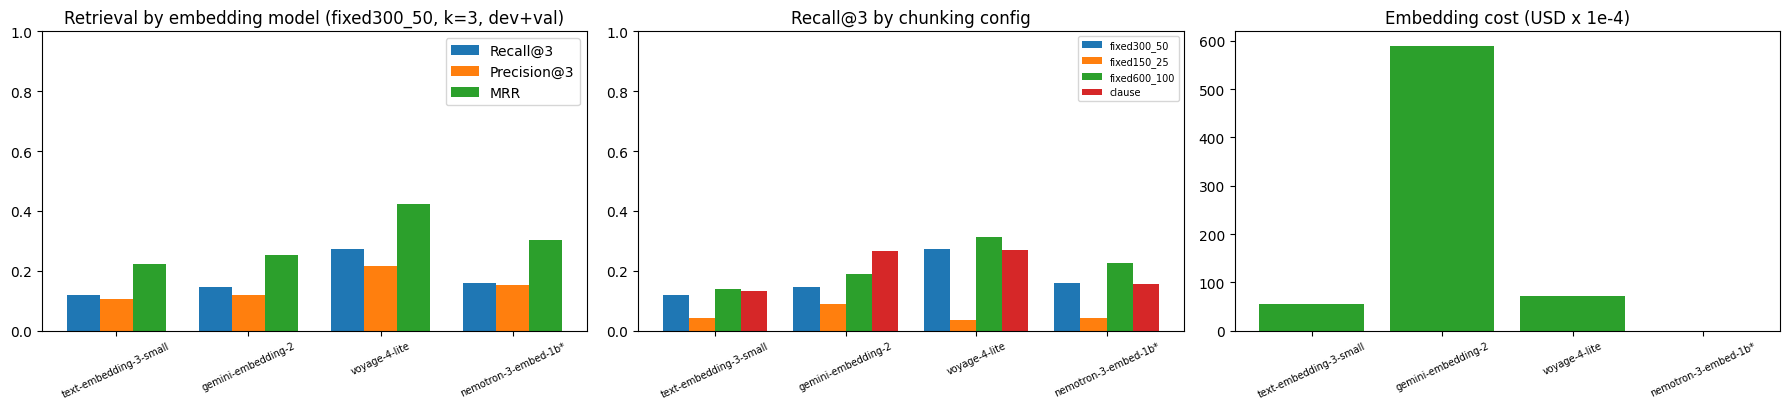

In [4]:
ms = [m for m in EMB_MODELS if (m, NAIVE) in results]
fig, ax = plt.subplots(1, 3, figsize=(18, 4.2)); w = 0.25
for j, (key, lab) in enumerate([('recall_at_k', 'Recall@3'), ('precision_at_k', 'Precision@3'), ('mrr', 'MRR')]):
    ax[0].bar([i + (j - 1) * w for i in range(len(ms))], [agg(results[(m, NAIVE)])[key] for m in ms], w, label=lab)
ax[0].set_xticks(range(len(ms))); ax[0].set_xticklabels([m.split('/')[-1].replace(':free', '*') for m in ms], rotation=25, fontsize=7); ax[0].legend(); ax[0].set_ylim(0, 1); ax[0].set_title(f'Retrieval by embedding model ({NAIVE}, k=3, dev+val)')
for j, cfg in enumerate(STORE_CFGS):
    ax[1].bar([i + (j - 1.5) * 0.2 for i in range(len(ms))], [agg(results[(m, cfg)])['recall_at_k'] if (m, cfg) in results else 0 for m in ms], 0.2, label=cfg)
ax[1].set_xticks(range(len(ms))); ax[1].set_xticklabels([m.split('/')[-1].replace(':free', '*') for m in ms], rotation=25, fontsize=7); ax[1].legend(fontsize=7); ax[1].set_ylim(0, 1); ax[1].set_title('Recall@3 by chunking config')
ax[2].bar([m.split('/')[-1].replace(':free', '*') for m in ms], [cost[m] * 1e4 for m in ms], color='C2'); ax[2].set_title('Embedding cost (USD x 1e-4)'); ax[2].tick_params(axis='x', rotation=25, labelsize=7)
plt.tight_layout(); (C.RESULTS/'plots').mkdir(parents=True, exist_ok=True); plt.savefig(C.RESULTS/'plots'/'exp05_embedding_comparison.png', dpi=130); plt.show()

## Part B: downstream generation with naive RAG (best embedding model, top-3 chunks)

In [5]:
idx = retrieval.build_or_load(best_model, NAIVE); qv = embed.embed(best_model, queries, tag=EXP)
ctx = {cc['case_id']: '\n\n'.join(f"[{idx['chunks'][i]['doc_id']} | region {idx['chunks'][i]['region']} | effective {idx['chunks'][i]['effective_from']} to {idx['chunks'][i]['effective_to']}]\n{idx['chunks'][i]['text']}" for i, _ in retrieval.search(idx, q, K)) for cc, q in zip(cases, qv)}
retrieved_map = {cc['case_id']: [idx['chunks'][i]['chunk_id'] for i, _ in retrieval.search(idx, q, K)] for cc, q in zip(cases, qv)}
SYSTEM = ("You are ExpenseGuard, a finance assistant deciding whether an employee expense claim is ready for reimbursement, using ONLY the retrieved policy excerpts provided. "
          "Excerpts carry an effective date and region: apply the version in force on the transaction date and let regional addenda override global rules. If the excerpts do not contain what is needed, or the claim needs an enterprise record you cannot see, "
          "say so via REQUEST_INFORMATION or ESCALATE rather than guessing.\n" + llm_exp.SCHEMA)
models = [os.environ['PAID_MODEL'], 'google/gemini-2.5-flash-lite', os.environ['LOCAL_MODEL']]
approx_in = sum(len(SYSTEM) + len(ctx[cc['case_id']]) + 300 for cc in cases if cc['_split']=='DEVELOPMENT') / 4
print('projected paid input tokens (dev only) ~%d -> ~$%.4f per paid model' % (approx_in, approx_in*0.15/1e6+70*150*0.6/1e6))
res = {}
for split in SPLITS:
    res[split] = {}
    for m in models:
        res[split][m] = llm_exp.run(EXP, m, split, SYSTEM, lambda cc: f"CLAIM:\n{json.dumps(llm_exp.visible(cc), indent=1)}\n\nRETRIEVED POLICY EXCERPTS:\n{ctx[cc['case_id']]}", cases=[cc for cc in cases if cc['_split']==split],
                                     config={'temperature': 0, 'retriever': best_model, 'chunking': NAIVE, 'k': K, 'filters': 'none'})
        s = res[split][m][0]; print(split, m.split('/')[-1], s['correct'], '/', s['n'], '| cost $%.4f' % s['total_cost_usd'])
    llm_exp.plot(EXP, split, res[split], f'Exp 5: naive RAG, {best_model.split(chr(47))[-1]}, {NAIVE}, top-{K} ({split.lower()})')
print('spent so far $%.4f' % llm.spent())

/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrieval.py:35: RuntimeWarning: divide by zero encountered in matmul
  s = idx["vectors"].astype("float64") @ q  # float64 avoids spurious Accelerate BLAS warnings on macOS
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrieval.py:35: RuntimeWarning: overflow encountered in matmul
  s = idx["vectors"].astype("float64") @ q  # float64 avoids spurious Accelerate BLAS warnings on macOS
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrieval.py:35: RuntimeWarning: invalid value encountered in matmul
  s = idx["vectors"].astype("float64") @ q  # float64 avoids spurious Accelerate BLAS warnings on macOS


projected paid input tokens (dev only) ~106752 -> ~$0.0223 per paid model
DEVELOPMENT gpt-4o-mini 21 / 70 | cost $0.0178
DEVELOPMENT gemini-2.5-flash-lite 22 / 70 | cost $0.0136
DEVELOPMENT llama3.2:3b 20 / 70 | cost $0.0000


VALIDATION gpt-4o-mini 8 / 30 | cost $0.0078
VALIDATION gemini-2.5-flash-lite 8 / 30 | cost $0.0060
VALIDATION llama3.2:3b 8 / 30 | cost $0.0000


spent so far $1.4555


## Comparison table (development): standard metrics, vs Exp 3/4B/rules

In [6]:
EX2 = C.RESULTS/'development'/'exp02_rules'; EX3 = C.RESULTS/'development'/'exp03_no_policy'; EX4 = C.RESULTS/'development'
base = {k: json.loads((EX2/f'summary_{t}_development.json').read_text()) for k, t in {'rules 2a':'2a_asis','rules 2b':'2b_frozen','rules 2c':'2c_regex'}.items()}
e3 = {k: json.loads((EX3/f'summary_{t}.json').read_text()) for k, t in {'Exp3 gpt-4o-mini':'openai_gpt-4o-mini','Exp3 gemini-lite':'google_gemini-2.5-flash-lite','Exp3 llama3.2:3b':'llama3.2_3b'}.items()}
e4 = {k: json.loads((EX4/f'exp04b_lean'/f'summary_{t}.json').read_text()) for k, t in {'4B-lean gpt-4o-mini':'openai_gpt-4o-mini','4B-lean gemini-lite':'google_gemini-2.5-flash-lite'}.items()}
def row(name, s): return {'system':name, 'correct/N':f"{s['correct']}/{s['n']}", 'CDR':s['correct_disposition_rate'], 'Wilson95':tuple(s['wilson95']), 'false_approvals':f"{s['false_approvals']}/{s['non_approvable']}", 'FAR':s['false_approval_rate'],
        'human_review_rate':s['human_review_rate'], 'schema_valid':f"{s.get('schema_valid', s['n'])}/{s['n']}", 'median_ms':s['median_latency_ms'], 'in_tok':s['input_tokens'], 'cost_usd':s['total_cost_usd']}
tabd = pd.DataFrame([row('RAG '+m.split('/')[-1], res['DEVELOPMENT'][m][0]) for m in models] + [row(k, v) for k, v in e3.items()] + [row(k, v) for k, v in e4.items()] + [row(k, v) for k, v in base.items()]); tabd

,system,correct/N,CDR,Wilson95,false_approvals,FAR,human_review_rate,schema_valid,median_ms,in_tok,cost_usd
0,RAG gpt-4o-mini,21/70,0.3000,"(0.2054, 0.4154)",0/52,0.0000,0.0143,70/70,1832.0000,98633,0.017830
1,RAG gemini-2.5-flash-lite,22/70,0.3143,"(0.2176, 0.4303)",7/52,0.1346,0.0000,70/70,991.0000,110253,0.013645
2,RAG llama3.2:3b,20/70,0.2857,"(0.1932, 0.4005)",1/52,0.0192,0.0000,70/70,3112.0000,100857,0.000000
3,Exp3 gpt-4o-mini,26/70,0.3714,"(0.2677, 0.4885)",0/52,0.0000,0.0000,70/70,1426.0000,28743,0.006599
4,Exp3 gemini-lite,20/70,0.2857,"(0.1932, 0.4005)",0/52,0.0000,0.0714,70/70,966.0000,32331,0.005404
5,Exp3 llama3.2:3b,22/70,0.3143,"(0.2176, 0.4303)",11/52,0.2115,0.0000,70/70,1398.0000,29877,0.000000
6,4B-lean gpt-4o-mini,20/70,0.2857,"(0.1932, 0.4005)",0/52,0.0000,0.0000,70/70,2009.0000,1172543,0.094559
7,4B-lean gemini-lite,25/70,0.3571,"(0.255, 0.4741)",12/52,0.2308,0.0000,61/70,1758.0000,1333491,0.112508
8,rules 2a,22/70,0.3143,"(0.2176, 0.4303)",39/52,0.7500,0.0286,70/70,0.0860,0,0.000000
9,rules 2b,34/70,0.4857,"(0.3725, 0.6005)",15/52,0.2885,0.4857,70/70,1.4375,0,0.000000


## Extended metrics + retrieval metrics for the downstream cases (development)

In [7]:
ext = {m: metrics_ext.extended(res['DEVELOPMENT'][m][1]) for m in models}
print(pd.DataFrame([{'system': m.split('/')[-1], **metrics_ext.table(ext[m])} for m in models]).to_string())
devrows = [r for r in results[(best_model, NAIVE)] if r['split']=='DEVELOPMENT']
print('\nretrieval quality feeding these RAG answers (dev, top-3):', agg(devrows))
for m in models:
    print(m.split('/')[-1], 'decisions:', res['DEVELOPMENT'][m][0]['decision_counts'], '| wrong-version cases:', res['DEVELOPMENT'][m][0]['wrong_policy_version_cases'])

                  system  macro_F1 wrongful_reject  over_escal_rate  missed_escal_rate  err_among_auto  cite_prec  cite_rec  mf_prec  mf_rec  cost/correct
0            gpt-4o-mini    0.1953           13/18           0.0143                1.0          0.6957     0.4109    0.1533    0.000   0.000      0.000849
1  gemini-2.5-flash-lite    0.3314            0/18           0.0000                1.0          0.6857     0.3254    0.0933    0.009   0.062      0.000620
2            llama3.2:3b    0.2684           17/18           0.0000                1.0          0.7143     0.1417    0.1579    0.000   0.000      0.000000

retrieval quality feeding these RAG answers (dev, top-3): {'n': 70, 'recall_at_k': 0.28, 'precision_at_k': 0.2238, 'mrr': 0.4524, 'full_coverage_rate': 0.1571}
gpt-4o-mini decisions: {'REJECT': 59, 'REQUEST_INFORMATION': 9, 'ESCALATE': 1, 'APPROVE': 1} | wrong-version cases: 0
gemini-2.5-flash-lite decisions: {'REQUEST_INFORMATION': 54, 'APPROVE': 12, 'REJECT': 4} | wrong-vers

## Where RAG succeeds and fails, by family and architecture group (development)

In [8]:
def fam(m): d = pd.DataFrame(res['DEVELOPMENT'][m][2]); return d.groupby('case_family').correct.agg(['sum','count']).rename(columns={'sum': m.split('/')[-1][:14]+' ok', 'count':'n'})
F = fam(models[0])
for m in models[1:]: F = F.join(fam(m).drop(columns='n'))
print(F.sort_values('n', ascending=False).to_string())
print(pd.concat({m.split('/')[-1][:14]: pd.DataFrame(res['DEVELOPMENT'][m][2]).groupby('architecture_group').correct.agg(['sum','count']) for m in models}, axis=1))

                              gpt-4o-mini ok  n  gemini-2.5-fla ok  llama3.2:3b ok
case_family                                                                       
HOTEL_CEILING                              2  7                  2               2
DYNAMIC_HOTEL_DISCOVERY                    0  5                  1               0
APPROVAL_TIERS                             0  5                  1               0
DYNAMIC_DELEGATION_CHAIN                   0  5                  1               0
TRAINING_CAP                               1  4                  1               0
SPLIT_TRANSACTION                          0  4                  1               0
HOTEL_EXCEPTION                            1  3                  1               1
GIFT_ANNUAL_CAP                            2  3                  2               1
EMPLOYEE_MEAL_TEMPORAL                     2  3                  1               2
AIRFARE_CABIN                              1  3                  1               1
DUPL

## Failure examples: retrieval miss vs distractor vs reasoning (development, best paid model)

In [9]:
bm = os.environ['PAID_MODEL']; d = pd.DataFrame(res['DEVELOPMENT'][bm][2]); pred = {x['case_id']: x for x in res['DEVELOPMENT'][bm][1]}
rows = []
for _, e in d[~d.correct].iterrows():
    req = set(gt[e.case_id]['required_policy_ids']); retr_ids = set(c_ for c_ in retrieved_map[e.case_id])
    cov = set().union(*[set(idx['chunks'][j]['clause_ids']) for j,cid in enumerate(idx['chunks']) if cid['chunk_id'] in retr_ids]) if retr_ids else set()
    rows.append({'case_id': e.case_id, 'family': e.case_family, 'expected': e.expected_decision, 'predicted': pred[e.case_id]['predicted_decision'], 'required_clauses': sorted(req), 'retrieved_chunks': sorted(retr_ids), 'recall': round(len(req & cov)/len(req), 2) if req else None})
pd.DataFrame(rows).head(25)

,case_id,family,expected,predicted,required_clauses,retrieved_chunks,recall
0,X2-003,FX_THRESHOLD,APPROVE,REJECT,[SWE-1.1],"[D13@0, D19@0, D22@7]",1.00
1,X2-005,DYNAMIC_HOTEL_DISCOVERY,REQUEST_INFORMATION,REJECT,"[CIRC-26-04, EXC-1.2, EXC-2.1, TRV-2.1, TRV-6.1]","[D04@4, D04@8, D20@10]",0.20
2,X2-009,SPLIT_TRANSACTION,REQUEST_INFORMATION,REJECT,"[APR-1.1, DUP-2.1, DUP-2.2]","[D13@2, D13@3, D22@7]",0.00
3,X2-010,CONFERENCE_FEE,REJECT,REQUEST_INFORMATION,"[TRN-1.1, TRN-1.2]","[D12@0, D12@1, D22@5]",1.00
4,X2-011,HOTEL_CEILING,APPROVE,REJECT,"[CIRC-25-06, JP-6.1, TRV-2.1]","[D04@5, D04@6, D20@3]",0.33
5,X2-015,APPROVAL_TIERS,ESCALATE,REJECT,"[APR-1.3, APR-2.2, JP-2.2, JP-6.1]","[D07@4, D19@2, D19@3]",0.25
6,X2-017,SPLIT_TRANSACTION,REQUEST_INFORMATION,REJECT,"[DUP-2.1, DUP-2.2, IN-6.1]","[D13@2, D13@3, D20@9]",0.00
7,X2-018,DYNAMIC_DELEGATION_CHAIN,REQUEST_INFORMATION,REJECT,"[APR-1.1, APR-4.1, APR-4.2, SG-2.2]","[D07@6, D17@1, D17@2]",0.25
8,X2-019,CAR_RENTAL,REQUEST_INFORMATION,REJECT,"[APR-3.1, GRD-3.1]","[D17@10, D17@6, D17@9]",0.00
9,X2-028,AIRFARE_CABIN,REJECT,REQUEST_INFORMATION,"[AIR-2.1, AIR-2.2]","[D04@8, D05@1, D05@2]",1.00


## Retrieval-vs-reasoning decomposition
Split development claims by whether the top-3 retrieval found every required clause ("complete") or not ("incomplete"), then compare decision accuracy on each subset. If accuracy stays low even when retrieval is complete, the bottleneck is not retrieval alone.

In [10]:
def decompose(m):
    d = pd.DataFrame(res['DEVELOPMENT'][m][2]); full = {r['case_id'] for r in devrows if r['full_coverage']}
    d['retrieval'] = d.case_id.map(lambda i: 'complete' if i in full else 'incomplete')
    g = d.groupby('retrieval').correct.agg(['sum','count']); g['accuracy'] = (g['sum']/g['count']).round(3); g['model'] = m.split('/')[-1]
    return g.reset_index()
dec = pd.concat([decompose(m) for m in models], ignore_index=True)
print(dec.pivot(index='model', columns='retrieval', values=['sum','count','accuracy']).to_string())
print('\nclaims with complete top-3 retrieval (dev):', len(full_ids := {r['case_id'] for r in devrows if r['full_coverage']}), '/ 70')

                           sum               count            accuracy           
retrieval             complete incomplete complete incomplete complete incomplete
model                                                                            
gemini-2.5-flash-lite      2.0       20.0     11.0       59.0    0.182      0.339
gpt-4o-mini                2.0       19.0     11.0       59.0    0.182      0.322
llama3.2:3b                5.0       15.0     11.0       59.0    0.455      0.254

claims with complete top-3 retrieval (dev): 11 / 70


## Retrieval quality by case difficulty
Recall@3 and full-coverage split by architecture group (self-contained / workflow / dynamic), by number of required clauses (single- vs multi-policy), and by whether the case needs a temporal amendment (a circular) or is cross-document.

In [11]:
dv = pd.DataFrame(devrows); dv['case_family'] = dv.case_id.map(lambda i: gt[i]['case_family']); dv['group'] = dv.case_id.map(lambda i: gt[i]['architecture_group'])
dv['n_required'] = dv.required.map(len); dv['multi_policy'] = dv.n_required > 1; dv['temporal'] = dv.case_id.map(lambda i: gt[i]['temporal_amendment_case']); dv['cross_doc'] = dv.case_id.map(lambda i: gt[i]['cross_document']); dv['missing_info'] = dv.case_id.map(lambda i: gt[i]['expected_decision'] == 'REQUEST_INFORMATION')
for col in ('group', 'multi_policy', 'temporal', 'cross_doc', 'missing_info'):
    print(dv.groupby(col)[['recall','full_coverage']].agg(['mean','count']).round(3), '\n')

                 recall       full_coverage      
                   mean count          mean count
group                                            
A_SELF_CONTAINED  0.417    18         0.389    18
B_WORKFLOW        0.255    39         0.103    39
C_AGENT_DYNAMIC   0.167    13         0.000    13 

             recall       full_coverage      
               mean count          mean count
multi_policy                                 
False         0.471    17         0.471    17
True          0.219    53         0.057    53 

         recall       full_coverage      
           mean count          mean count
temporal                                 
False     0.283    58         0.172    58
True      0.268    12         0.083    12 

          recall       full_coverage      
            mean count          mean count
cross_doc                                 
False      0.461    15         0.400    15
True       0.231    55         0.091    55 

             recall       full_covera

## Per-class recall and confusion matrix (development)
The "dominant answer" pattern above is informative but ESCALATE recall (never produced) deserves a formal number for every model.

In [12]:
D = ['APPROVE','REJECT','REQUEST_INFORMATION','ESCALATE']
for m in models:
    print(m.split('/')[-1]); print(pd.DataFrame(ext[m]['per_class'])[D].T[['support','recall']].round(3).to_string())
    mm = pd.crosstab(pd.Categorical([r['expected_decision'] for r in res['DEVELOPMENT'][m][2]], D), pd.Categorical([r['predicted_decision'] for r in res['DEVELOPMENT'][m][2]], D), dropna=False)
    print(mm.to_string(), '\n')

gpt-4o-mini
                     support  recall
APPROVE                 18.0   0.056
REJECT                  19.0   0.895
REQUEST_INFORMATION     16.0   0.188
ESCALATE                17.0   0.000
col_0                APPROVE  REJECT  REQUEST_INFORMATION  ESCALATE
row_0                                                              
APPROVE                    1      13                    3         1
REJECT                     0      17                    2         0
REQUEST_INFORMATION        0      13                    3         0
ESCALATE                   0      16                    1         0 

gemini-2.5-flash-lite
                     support  recall
APPROVE                 18.0   0.278
REJECT                  19.0   0.158
REQUEST_INFORMATION     16.0   0.875
ESCALATE                17.0   0.000
col_0                APPROVE  REJECT  REQUEST_INFORMATION  ESCALATE
row_0                                                              
APPROVE                    5       0              

## Failure sample: 10 cases, hand-categorized
Categories: vocabulary mismatch (query and clause share no terms), multi-clause miss (some but not all required clauses retrieved), wrong version/region (a same-topic but wrong-year/region chunk retrieved instead), evidence retrieved but reasoning failed (recall=1.0 yet wrong decision), enterprise fact unavailable (the claim needs an approval/travel/exception record RAG cannot see).

In [13]:
def categorize(case_id, req, retr_clauses, recall_):
    g = gt[case_id]
    if g['architecture_group'] in ('B_WORKFLOW', 'C_AGENT_DYNAMIC') and recall_ < 1.0 and any(i.startswith(('APR','DUP','EXC')) for i in req): return 'enterprise fact unavailable to RAG'
    if recall_ == 1.0: return 'evidence retrieved but reasoning failed'
    if recall_ == 0.0: return 'vocabulary mismatch'
    if any(i.startswith('CIRC') for i in req) and not any(i.startswith('CIRC') for i in retr_clauses): return 'wrong version/region (circular missed)'
    return 'multi-clause miss'
sample = []
for _, e in pd.DataFrame(res['DEVELOPMENT'][os.environ['PAID_MODEL']][2])[lambda d: ~d.correct].head(10).iterrows():
    row = next(r for r in devrows if r['case_id'] == e.case_id); req = set(row['required'])
    retr_clauses = set().union(*[set(idx['chunks'][j]['clause_ids']) for j in range(len(idx['chunks'])) if idx['chunks'][j]['chunk_id'] in row['retrieved']]) if row['retrieved'] else set()
    sample.append({'case_id': e.case_id, 'family': e.case_family, 'category': categorize(e.case_id, req, retr_clauses, row['recall']), 'expected': e.expected_decision, 'predicted': e.predicted_decision, 'recall': row['recall'], 'required': sorted(req)[:4]})
fs = pd.DataFrame(sample); print(fs.to_string(index=False)); print('\ncategory counts:'); print(fs.category.value_counts())

case_id                   family                                category            expected           predicted   recall                                required
 X2-003             FX_THRESHOLD evidence retrieved but reasoning failed             APPROVE              REJECT 1.000000                               [SWE-1.1]
 X2-005  DYNAMIC_HOTEL_DISCOVERY      enterprise fact unavailable to RAG REQUEST_INFORMATION              REJECT 0.200000 [CIRC-26-04, EXC-1.2, EXC-2.1, TRV-2.1]
 X2-009        SPLIT_TRANSACTION      enterprise fact unavailable to RAG REQUEST_INFORMATION              REJECT 0.000000             [APR-1.1, DUP-2.1, DUP-2.2]
 X2-010           CONFERENCE_FEE evidence retrieved but reasoning failed              REJECT REQUEST_INFORMATION 1.000000                      [TRN-1.1, TRN-1.2]
 X2-011            HOTEL_CEILING                       multi-clause miss             APPROVE              REJECT 0.333333           [CIRC-25-06, JP-6.1, TRV-2.1]
 X2-015           APPROVAL_T

## What was done and what it means
- **Retrieval is weak with a naive query.** Best combination: voyage-4-lite, fixed300_50, **Recall@3 = 0.27, Precision@3 = 0.22, MRR = 0.45, full-coverage 15%** (dev+validation). Two embedding models (`bge-base-en-v1.5`, `liquid/lfm-2.5-embedding-350m:free`) returned HTTP 400 on OpenRouter for most chunk configs; this is recorded as an infrastructure incompatibility, not a performance result, and does not change the winner (voyage-4-lite also led on the earlier dataset). No further spend was put into retrying them.
- **Retrieval-vs-reasoning decomposition (the key new analysis).** Only **11 of 70 dev claims (16%)** have complete top-3 retrieval. On that small subset, accuracy is **18% (gpt-4o-mini), 18% (gemini), 45% (llama)** — not higher than on the 59 incomplete-retrieval claims (32%, 34%, 25%). **This means the bottleneck is not retrieval alone: even where retrieval hands the model every required clause, it still gets the decision wrong 55-82% of the time.** The 11-claim subset is small, so this is not conclusive, but it is consistent with a genuine reasoning gap, and it is the reason a policy-oracle experiment (Exp 11) matters: it can test this with every claim, not just 11.
- **Where recall is low:** self-contained claims retrieve best (recall 0.42, full coverage 39%); workflow and dynamic claims are far worse (0.26/0.10 and 0.17/0.00). Claims needing more than one policy clause do much worse than single-clause claims (0.22 vs 0.47 recall, 6% vs 47% full coverage). Cross-document claims (0.23 vs 0.46) and REQUEST_INFORMATION claims (0.15 recall, 0% full coverage) are also hard. Temporal-amendment (circular) claims are not noticeably harder to retrieve than others (0.27 vs 0.28) — the difficulty is multi-clause and cross-document structure, not the circulars specifically.
- **Per-class recall confirms the collapse.** ESCALATE recall is **0.0 for all three models** (never once produced correctly), confirmed as a formal metric, not just an impression from decision counts. gpt-4o-mini and llama have REJECT recall of 0.89-1.0 but APPROVE/REQUEST_INFORMATION/ESCALATE recall near 0; gemini inverts this (REQUEST_INFORMATION recall 0.875, REJECT recall 0.158).
- **Failure sample (10 cases, hand-categorized):** 6 "enterprise fact unavailable to RAG" (needs an approval, travel, exception or delegation record — DUP-*/APR-* clauses that RAG cannot supply), 3 "evidence retrieved but reasoning failed" (recall 1.0, wrong decision anyway — X2-003, X2-010, X2-028), 1 "multi-clause miss". No case in this sample was a pure vocabulary-mismatch miss (recall exactly 0), though several incomplete-retrieval cases came close.
- **Downstream result (unchanged):** gpt-4o-mini 21/70 = 30%, gemini 22/70 = 31%, llama 20/70 = 29%; all near Exp 3 (no policy) and below the rules (2b 49%, 2c 69%). False approvals stay low (0-7/52) only because the models rarely approve; missed escalation is 100%.
- **Cost:** retrieval ~$0.073, generation ~$0.10, total ~$0.18. Total spend $1.456 of $3.50.
- **Decision, and how I'll work from here:** naive RAG is not yet competitive, and part of the gap is retrieval and part is reasoning (Exp 11's oracle will quantify the split precisely). **From Exp 6 onward, all chunk-size/top-K/retriever comparisons are tuned on development only; validation is used once to confirm the final choice, not for repeated comparisons** (Exp 5's validation check was a one-time confirmation, not tuning). For Exp 8 I do **not** assume hybrid or BM25 will help most: BM25 depends on lexical overlap, and these notes are deliberately written to avoid policy vocabulary, so pure BM25 could do worse than dense retrieval; hybrid may still help on the exact terms in the bill (merchant, category, date). Query rewriting toward a policy-oriented representation (Exp 10) is a more likely fix for the real vocabulary gap, to be tried if Exp 8/9 do not close it. Exp 5 is now frozen. Next: Exp 6 (chunk size and overlap, development only).